# 🚢 Titanic Survival Prediction using Machine Learning

## 📌 Internship Task 3

### 📖 Project Overview
This project predicts whether a passenger survived the Titanic disaster using Machine Learning classification models.

The project includes:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Feature Importance
- Model Saving
- Prediction Example

---

## 🎯 Objective

Build a classification model that predicts passenger survival using demographic and travel information while applying feature engineering, preprocessing, and explainable machine learning techniques.

---

### 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

---

# Import Libraries

Import all required libraries for data manipulation, visualization, machine learning, and model saving.

In [108]:

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


#  Load Dataset

Load the Titanic dataset into a Pandas DataFrame.

In [109]:

df = pd.read_csv("titanic.csv")

print("Dataset Loaded Successfully!\n")

print("Shape of Dataset:")
print(df.shape)

Dataset Loaded Successfully!

Shape of Dataset:
(418, 12)


In [110]:
# Display first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


#  Exploratory Data Analysis

Understand the dataset using summary statistics, missing values, and visualizations.

In [111]:
# ==========================
# Basic Information
# ==========================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (418, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    i

In [112]:
# ==========================
# Statistical Summary
# ==========================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,418.0,NaN,NaN,NaN,1100.5,120.810458,892.0,996.25,1100.5,1204.75,1309.0
Survived,418.0,NaN,NaN,NaN,0.363636,0.481622,0.0,0.0,0.0,1.0,1.0
Pclass,418.0,NaN,NaN,NaN,2.26555,0.841838,1.0,1.0,3.0,3.0,3.0
Name,418,418,"Peter, Master. Michael J",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,418,2,male,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
SibSp,418.0,NaN,NaN,NaN,0.447368,0.89676,0.0,0.0,0.0,1.0,8.0
Parch,418.0,NaN,NaN,NaN,0.392344,0.981429,0.0,0.0,0.0,0.0,9.0
Ticket,418,363,PC 17608,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292


In [113]:
# ==========================
# Missing Values
# ==========================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing[missing["Missing Values"] > 0]

,Missing Values,Percentage
Age,86,20.57
Fare,1,0.24
Cabin,327,78.23


In [114]:
# ==========================
# Duplicate Check
# ==========================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [115]:
# ==========================
# Unique Values
# ==========================

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

PassengerId: 418 unique values
Survived: 2 unique values
Pclass: 3 unique values
Name: 418 unique values
Sex: 2 unique values
Age: 79 unique values
SibSp: 7 unique values
Parch: 8 unique values
Ticket: 363 unique values
Fare: 169 unique values
Cabin: 76 unique values
Embarked: 3 unique values


Data Visualization (EDA)

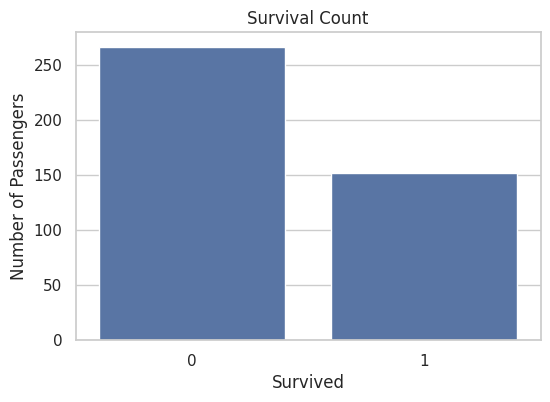

In [116]:
# ==========================
# Survival Count
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

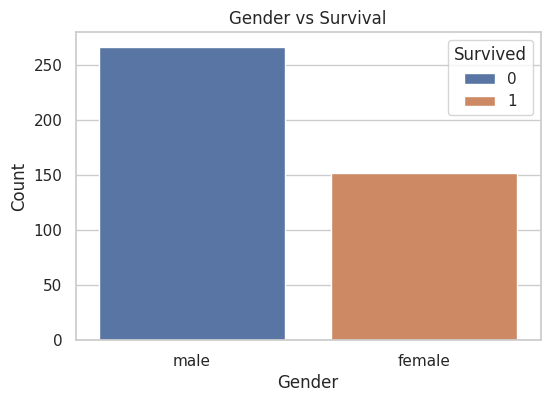

In [117]:
# ==========================
# Gender vs Survival
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Gender vs Survival")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

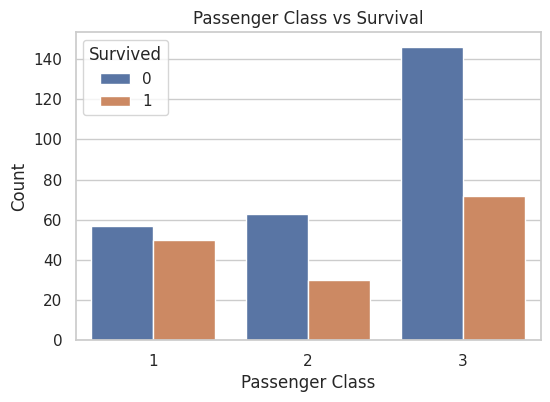

In [118]:
# ==========================
# Passenger Class vs Survival
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

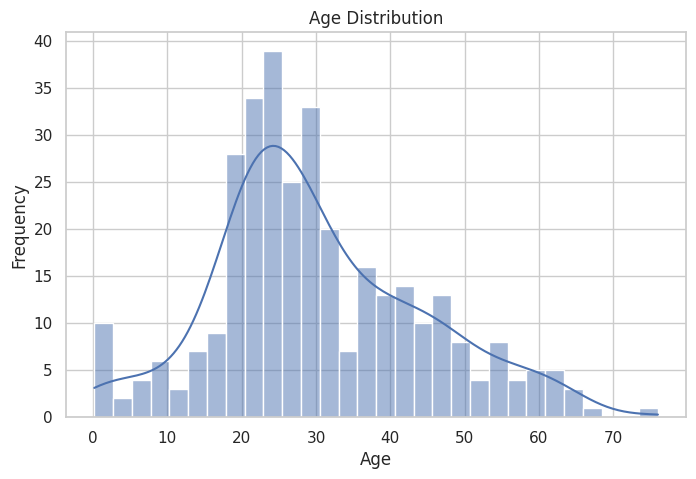

In [119]:
# ==========================
# Age Distribution
# ==========================

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

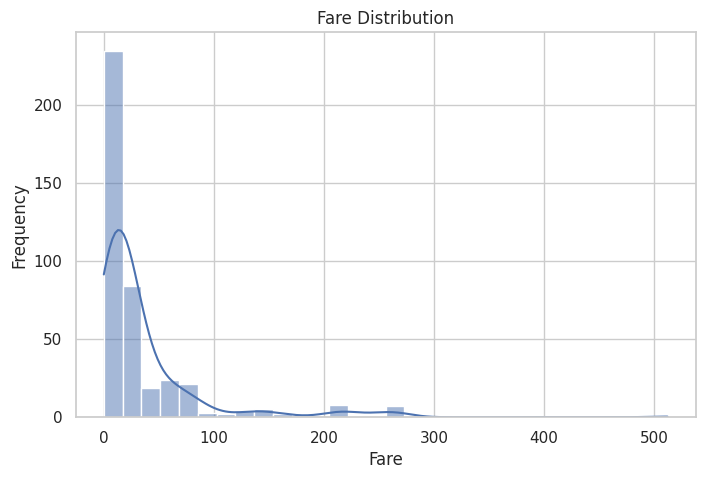

In [120]:
# ==========================
# Fare Distribution
# ==========================

plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

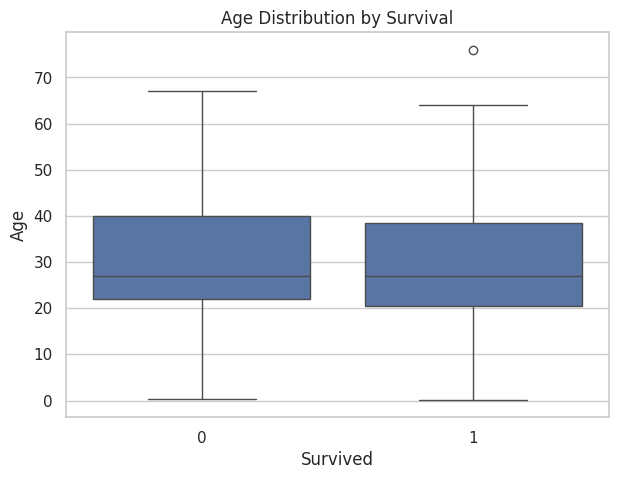

In [121]:
# ==========================
# Age vs Survival
# ==========================

plt.figure(figsize=(7,5))

sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")

plt.show()

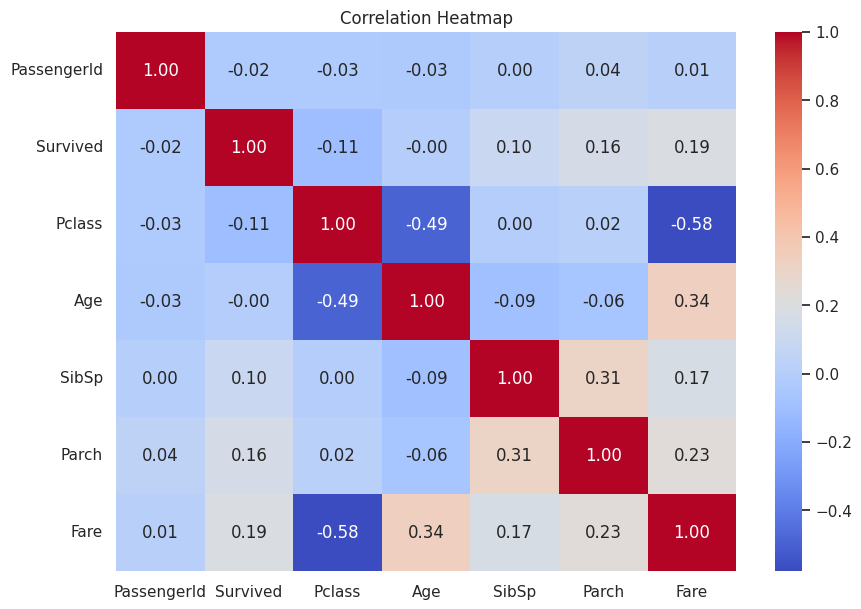

In [122]:
# ==========================
# Correlation Heatmap
# ==========================

plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

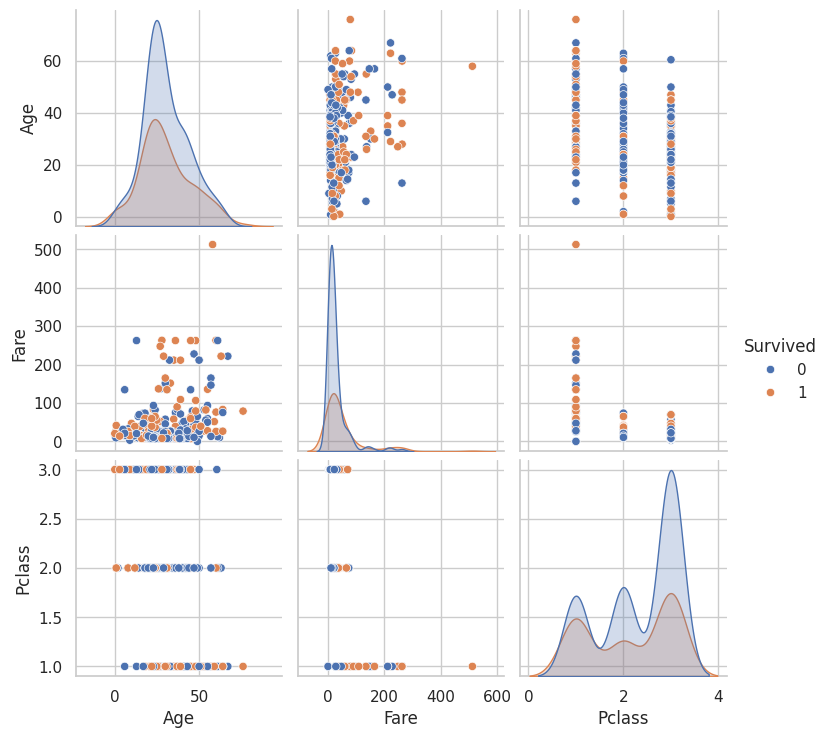

In [123]:
# ==========================
# Pairplot
# ==========================

sns.pairplot(
    df[['Survived','Age','Fare','Pclass']],
    hue='Survived'
)

plt.show()

#  Feature Engineering

Create new features such as:

- Title
- Family Size
- Is Alone
- Has Cabin

In [124]:
# ==========================
# Create a Working Copy
# ==========================

data = df.copy()

print("Working copy created successfully!")

Working copy created successfully!


In [125]:
# ==========================
# Extract Passenger Title
# ==========================

data["Title"] = data["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

data["Title"].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [126]:
# ==========================
# Group Rare Titles
# ==========================

common_titles = ["Mr", "Miss", "Mrs", "Master"]

data["Title"] = data["Title"].apply(
    lambda x: x if x in common_titles else "Other"
)

data["Title"].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Other,7


In [127]:
# ==========================
# Family Size
# ==========================

data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

data[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,0,0,1
1,1,0,2
2,0,0,1
3,0,0,1
4,1,1,3


In [128]:
# ==========================
# Is Alone
# ==========================

data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

data[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,1,1
1,2,0
2,1,1
3,1,1
4,3,0


In [129]:
# ==========================
# Has Cabin
# ==========================

data["HasCabin"] = data["Cabin"].notnull().astype(int)

data[["Cabin", "HasCabin"]].head()

,Cabin,HasCabin
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [130]:
# ==========================
# New Features
# ==========================

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,HasCabin
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,1,1,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,2,0,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,1,1,0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,1,1,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,3,0,0


In [131]:
# ==========================
# Handle Missing Values
# ==========================

# Fill missing Age with median
data["Age"].fillna(data["Age"].median(), inplace=True)

# Fill missing Embarked with mode
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [132]:
# ==========================
# Verify Missing Values
# ==========================

data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1


In [133]:
# Fill missing Fare value
data["Fare"] = data["Fare"].fillna(data["Fare"].median())


In [134]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#  Model Training

Train three different Machine Learning models and compare their performance.

In [135]:
# ==========================
# Encode Categorical Features
# ==========================

label_encoder = LabelEncoder()

categorical_columns = ["Sex", "Embarked", "Title"]

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

print("Categorical variables encoded successfully!")

Categorical variables encoded successfully!


In [136]:
# ==========================
# Drop Unnecessary Columns
# ==========================

data = data.drop(columns=[
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
])

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin
0,0,3,1,34.5,0,0,7.8292,1,2,1,1,0
1,1,3,0,47.0,1,0,7.0000,2,3,2,0,0
2,0,2,1,62.0,0,0,9.6875,1,2,1,1,0
3,0,3,1,27.0,0,0,8.6625,2,2,1,1,0
4,1,3,0,22.0,1,1,12.2875,2,3,3,0,0


In [137]:
# ==========================
# Features & Target
# ==========================

X = data.drop("Survived", axis=1)
y = data["Survived"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (418, 11)
Target Shape: (418,)


In [138]:
# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (334, 11)
Testing Set : (84, 11)


#  Model Evaluation

Evaluate the trained models using multiple classification metrics.

In [139]:
# ==========================
# Logistic Regression
# ==========================

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [140]:
# ==========================
# Decision Tree
# ==========================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [141]:
# ==========================
# Random Forest
# ==========================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [142]:
# ==========================
# Model Comparison
# ==========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


In [143]:
# ==========================
# Random Forest Evaluation
# ==========================

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [144]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



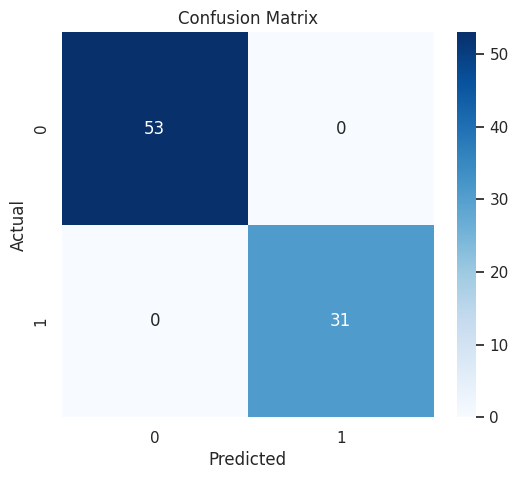

In [145]:
# ==========================
# Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#  Feature Importance

Analyze the most influential features affecting survival prediction.

In [146]:


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Sex,0.561043
7,Title,0.328947
5,Fare,0.028707
2,Age,0.021504
8,FamilySize,0.017126
4,Parch,0.015310
9,IsAlone,0.007147
3,SibSp,0.006242
0,Pclass,0.004730
6,Embarked,0.004692


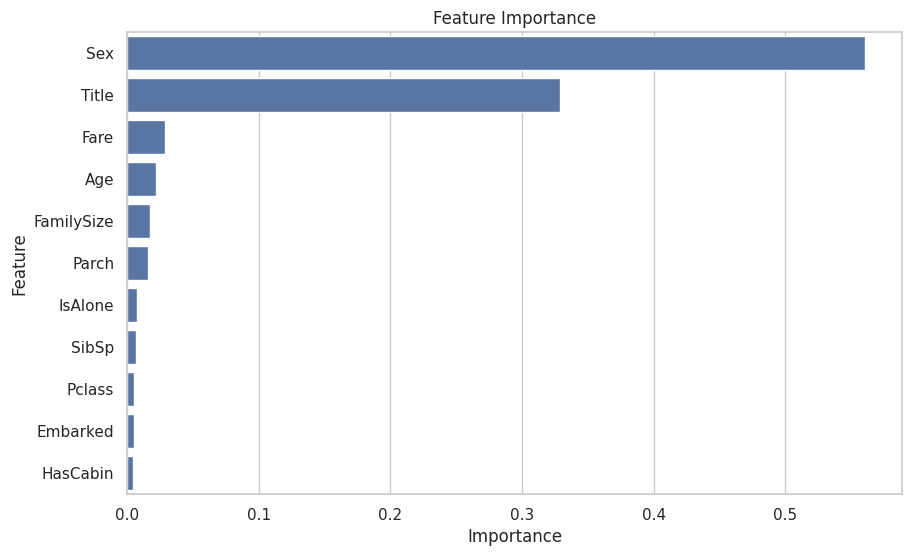

In [147]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Save Model

Save the trained Random Forest model using Joblib.

In [148]:

joblib.dump(rf, "titanic_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


#  Prediction Example

Predict survival for a sample passenger using the trained model.

In [149]:


sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Prediction: 0
Passenger Did Not Survive


# ✅ Conclusion

In this project, we successfully developed a Machine Learning model to predict Titanic passenger survival.

### Achievements

✔ Data Cleaning

✔ Exploratory Data Analysis

✔ Feature Engineering

✔ Model Training

✔ Model Evaluation

✔ Feature Importance

✔ Model Saving

✔ Prediction Example

Among all the models, the **Random Forest Classifier** achieved the best performance and was selected as the final model.

---

Thank You!